<div style="text-align:center">

# Instituto Politécnico Nacional  
## Escuela Superior de Cómputo  
### Ingeniería en Sistemas Computacionales  
### Inteligencia Artificial  

# Práctica: Clasificador Naive Bayes

**Alumnos:**  
De la Cruz Velázquez Marco Uriel  
Sánchez Gómez Alan Iván  
Solís Lugo Mayra  

**Profesor:** Andrés García Floriano  
**Fecha:** 01 de junio de 2026

</div>


# Índice

1. Introducción  
2. Objetivos  
3. Fundamento teórico  
4. Datasets utilizados  
5. Implementación del clasificador  
6. Funciones de análisis y visualización  
7. Análisis del dataset Iris  
8. Análisis del dataset Wine  
9. Comparación general  
10. Discusión  
11. Conclusiones  
12. Referencias


# 1. Introducción

En esta práctica trabajamos con el clasificador **Naive Bayes Gaussiano**, que básicamente intenta decidir a qué clase pertenece una muestra usando probabilidades. Al principio parece un modelo demasiado simple, porque asume que las características son independientes entre sí, pero justo por eso me pareció interesante probarlo: quería ver qué tan lejos puede llegar con una suposición que en datos reales casi nunca se cumple al 100%.

Para hacer las pruebas se usaron dos datasets clásicos: **Iris** y **Wine**. Iris fue el más cómodo para empezar porque sólo tiene cuatro variables y sus clases se entienden rápido. Wine, por otro lado, ya tiene trece características químicas, entonces ahí fue menos inmediato interpretar todo, sobre todo las matrices de correlación.

La práctica no se hizo únicamente con `GaussianNB` de Scikit-Learn. También se implementó una versión manual del clasificador para revisar qué pasa por dentro: cálculo de probabilidades a priori, medias, desviaciones estándar y verosimilitudes. La verdad, esta parte ayuda bastante porque usar la biblioteca directamente es fácil, pero no siempre queda claro qué está calculando el modelo en cada paso.

Algo que se cuidó durante el notebook fue comparar la implementación manual con Scikit-Learn usando los mismos métodos de validación. Así se puede revisar si el código propio está siguiendo la misma lógica y no solamente “da un número bonito” por casualidad.


# 2. Objetivos

## Objetivo general

Implementar y evaluar un clasificador **Naive Bayes Gaussiano** utilizando dos datasets multiclase, analizando sus parámetros estadísticos, sus supuestos principales y su desempeño mediante diferentes métodos de validación.

## Objetivos específicos

- Calcular las probabilidades a priori de cada clase.
- Obtener la media y desviación estándar de cada característica por clase.
- Visualizar la distribución de las características mediante gráficas KDE.
- Analizar la correlación entre características para revisar la suposición de independencia.
- Implementar manualmente el clasificador Gaussian Naive Bayes.
- Evaluar el modelo con Hold-Out 80/20, 10-Fold Cross Validation y Leave-One-Out.
- Comparar los resultados de la implementación manual con Scikit-Learn.


# 3. Fundamento teórico

## 3.1 Teorema de Bayes

El Teorema de Bayes permite calcular la probabilidad de una clase considerando la evidencia observada. En clasificación, la evidencia corresponde a las características de una muestra.

$$
P(C_k \mid X)=\frac{P(X \mid C_k)P(C_k)}{P(X)}
$$

Donde:

- $P(C_k \mid X)$ es la probabilidad posterior de que la muestra pertenezca a la clase $C_k$.
- $P(X \mid C_k)$ es la verosimilitud, es decir, qué tan probable es observar esas características si la muestra pertenece a esa clase.
- $P(C_k)$ es la probabilidad a priori de la clase.
- $P(X)$ es la evidencia.

En la práctica, para clasificar no es necesario calcular completamente $P(X)$, porque ese valor es el mismo para todas las clases. Por eso se compara la parte proporcional de la probabilidad posterior.


## 3.2 Naive Bayes Gaussiano

Naive Bayes se llama “naive” porque asume que las características son independientes entre sí, siempre que ya se conozca la clase. Esta simplificación hace que el cálculo sea mucho más sencillo.

Cuando las variables son numéricas continuas, se suele usar la variante **Gaussiana**, donde se supone que cada característica sigue aproximadamente una distribución normal dentro de cada clase.

La función de densidad Gaussiana utilizada es:

$$
P(x_i \mid C_k)=\frac{1}{\sqrt{2\pi}\sigma_k}e^{-\frac{(x_i-\mu_k)^2}{2\sigma_k^2}}
$$

En esta fórmula, $\mu_k$ representa la media de una característica para una clase y $\sigma_k$ su desviación estándar. Con esos dos valores se estima qué tan probable es observar un valor específico dentro de una clase.


## 3.3 Métodos de validación

Para evaluar el modelo no basta con entrenarlo y revisar si funciona con los mismos datos. Es necesario probarlo con datos que no haya visto durante el entrenamiento.

En esta práctica se usan tres métodos:

**Hold-Out 80/20:** separa 80% de los datos para entrenamiento y 20% para prueba. Es rápido, aunque depende de cómo se realice la división.

**10-Fold Cross Validation:** divide el dataset en 10 partes. El modelo se entrena y prueba 10 veces, cambiando la partición usada para prueba. Suele dar una evaluación más estable.

**Leave-One-Out:** usa una sola muestra como prueba en cada iteración y entrena con todas las demás. Es más exhaustivo, pero también más costoso.


# 4. Datasets utilizados

## 4.1 Dataset Iris

El dataset Iris contiene mediciones de flores de tres especies diferentes. Es muy usado en clasificación porque sus características son numéricas, sus clases están bien definidas y su tamaño permite analizarlo fácilmente.

| Aspecto | Descripción |
|---|---|
| Muestras | 150 |
| Características | 4 |
| Clases | Setosa, Versicolor y Virginica |
| Tipo de problema | Clasificación multiclase |

Las características son longitud y ancho del sépalo, además de longitud y ancho del pétalo. Al tener pocas variables, es un buen punto de partida para revisar si el algoritmo funciona correctamente.

## 4.2 Dataset Wine

El dataset Wine contiene mediciones químicas de diferentes muestras de vino. A diferencia de Iris, tiene más características, por lo que el análisis de correlación y la suposición de independencia se vuelven más importantes.

| Aspecto | Descripción |
|---|---|
| Muestras | 178 |
| Características | 13 |
| Clases | 3 clases de vino |
| Tipo de problema | Clasificación multiclase |

Este dataset permite observar cómo se comporta Naive Bayes cuando hay más variables y posibles relaciones entre ellas.


# 5. Implementación del clasificador

Primero se cargan las bibliotecas necesarias. Aquí se usan `NumPy` y `Pandas` para manejar los datos, `Matplotlib` y `Seaborn` para las gráficas, y Scikit-Learn para cargar los datasets y comparar nuestra implementación manual con una implementación ya probada.

La idea fue dejar el código lo más directo posible, aunque algunas partes se repiten un poco en la función general. Preferí eso porque así es más fácil revisar qué se está calculando en cada dataset.


In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB

# Dejo esta configuración aquí para no estar ajustando el tamaño de cada gráfica a mano
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


## 5.1 Clasificador Gaussian Naive Bayes manual

La siguiente clase contiene la implementación manual del clasificador. La intención no fue “competir” contra Scikit-Learn, sino comprobar que entendimos qué calcula el modelo.

En general, la clase hace tres cosas:

- `fit()`: guarda los parámetros estadísticos de cada clase.
- `gaussian_pdf()`: calcula la densidad de probabilidad con la fórmula Gaussiana.
- `predict()`: compara las probabilidades de cada clase y elige la mayor.

Un detalle importante está en `predict()`: se usan logaritmos. Esto se hace porque al multiplicar muchas probabilidades pequeñas pueden aparecer problemas numéricos. Con logaritmos, esas multiplicaciones se convierten en sumas y el cálculo se vuelve más estable.


In [25]:
class GaussianNaiveBayesManual:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.std = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]

            # Para cada clase guardamos sus promedios; esto es lo que después usa la Gaussiana
            self.mean[c] = X_c.mean(axis=0)

            # Le sumo un valor muy pequeño para evitar división entre cero si alguna desviación sale rara
            self.std[c] = X_c.std(axis=0) + 1e-9

            # Probabilidad inicial de la clase, antes de ver las características de la muestra
            self.priors[c] = len(X_c) / len(X)

    def gaussian_pdf(self, x, mean, std):
        # Fórmula de densidad normal; aquí se evalúa qué tan probable es cada característica
        exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
        return (1 / (np.sqrt(2 * np.pi) * std)) * exponent

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = []

            for c in self.classes:
                # Aquí usamos logaritmos para evitar underflow, lo vimos como truco común en clase
                prior = np.log(self.priors[c])

                # En vez de multiplicar probabilidades pequeñas, sumamos sus logs
                likelihood = np.sum(np.log(self.gaussian_pdf(x, self.mean[c], self.std[c])))

                # Esta es la “calificación” final de la clase para la muestra actual
                posterior = prior + likelihood
                posteriors.append(posterior)

            # Nos quedamos con la clase que tuvo mayor probabilidad posterior
            predictions.append(self.classes[np.argmax(posteriors)])

        return np.array(predictions)


# 6. Funciones de análisis y visualización

Para no repetir todo el procedimiento con Iris y Wine, se creó la función `analizar_dataset()`. Esta función recibe el nombre del dataset y el objeto cargado desde Scikit-Learn.

Dentro de la función se calculan las probabilidades a priori, medias, desviaciones estándar, gráficas KDE, matrices de correlación y las validaciones del modelo. También se compara la implementación manual contra `GaussianNB`, que sirve como referencia para detectar si nuestra implementación se comporta parecido.


In [26]:
def analizar_dataset(nombre, dataset):
    print("\n" + "="*70)
    print(f"DATASET: {nombre}")
    print("="*70)

    X = dataset.data
    y = dataset.target
    feature_names = dataset.feature_names
    target_names = dataset.target_names

    df = pd.DataFrame(X, columns=feature_names)
    df["class"] = y
    df["class_name"] = df["class"].apply(lambda i: target_names[i])

    print(f"\nNúmero de muestras: {X.shape[0]}")
    print(f"Número de características: {X.shape[1]}")
    print(f"Clases: {list(target_names)}")

    # Primero vemos qué tan cargado está el dataset hacia cada clase
    print("\nProbabilidades a priori por clase:")
    priors = df["class_name"].value_counts(normalize=True)
    display(priors.to_frame(name="Probabilidad a priori"))

    # Estos son los parámetros que realmente necesita el Naive Bayes Gaussiano
    print("\nMedia y desviación estándar por característica y clase:")
    stats_by_class = {}

    for clase in target_names:
        subset = df[df["class_name"] == clase]
        stats = subset[feature_names].agg(["mean", "std"]).T
        stats_by_class[clase] = stats
        print(f"\nClase: {clase}")
        display(stats)

    # Las KDE ayudan a ver si las clases se separan o si se enciman mucho
    print("\nGráficas KDE por característica:")
    for feature in feature_names:
        plt.figure(figsize=(8, 5))

        for clase in target_names:
            subset = df[df["class_name"] == clase]
            sns.kdeplot(subset[feature], label=clase, fill=False)

        plt.title(f"KDE de {feature} por clase - {nombre}")
        plt.xlabel(feature)
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Revisamos correlaciones porque el supuesto de independencia es medio fuerte
    print("\nMatrices de correlación por clase:")
    for clase in target_names:
        subset = df[df["class_name"] == clase]

        plt.figure(figsize=(9, 7))
        sns.heatmap(subset[feature_names].corr(), annot=True, cmap="coolwarm", fmt=".2f")
        plt.title(f"Matriz de correlación - Clase {clase} - {nombre}")
        plt.show()

    # Primera prueba: una división rápida 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    modelo_manual = GaussianNaiveBayesManual()
    modelo_manual.fit(X_train, y_train)
    y_pred_manual = modelo_manual.predict(X_test)
    acc_manual = accuracy_score(y_test, y_pred_manual)

    print("\nHold-Out 80/20 - Naive Bayes Manual")
    print(f"Accuracy: {acc_manual:.4f}")
    print(classification_report(y_test, y_pred_manual, target_names=target_names))

    modelo_sklearn = GaussianNB()
    modelo_sklearn.fit(X_train, y_train)
    y_pred_sklearn = modelo_sklearn.predict(X_test)
    acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

    print("\nHold-Out 80/20 - GaussianNB Scikit-Learn")
    print(f"Accuracy: {acc_sklearn:.4f}")
    print(classification_report(y_test, y_pred_sklearn, target_names=target_names))

    # Ahora hacemos 10-Fold para no depender de una sola partición
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores_manual = []

    for train_index, test_index in kfold.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        modelo = GaussianNaiveBayesManual()
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        scores_manual.append(accuracy_score(y_test, y_pred))

    scores_sklearn = cross_val_score(GaussianNB(), X, y, cv=kfold)

    print("\n10-Fold Cross-Validation - Manual")
    print(f"Accuracy promedio: {np.mean(scores_manual):.4f}")
    print(f"Desviación estándar: {np.std(scores_manual):.4f}")

    print("\n10-Fold Cross-Validation - Scikit-Learn")
    print(f"Accuracy promedio: {scores_sklearn.mean():.4f}")
    print(f"Desviación estándar: {scores_sklearn.std():.4f}")

    # Leave-One-Out tarda más, pero aprovecha casi todo para entrenar en cada vuelta
    loo = LeaveOneOut()
    scores_loo_manual = []

    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        modelo = GaussianNaiveBayesManual()
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        scores_loo_manual.append(accuracy_score(y_test, y_pred))

    scores_loo_sklearn = cross_val_score(GaussianNB(), X, y, cv=loo)

    print("\nLeave-One-Out - Manual")
    print(f"Accuracy promedio: {np.mean(scores_loo_manual):.4f}")

    print("\nLeave-One-Out - Scikit-Learn")
    print(f"Accuracy promedio: {scores_loo_sklearn.mean():.4f}")

    resumen = {
        "Dataset": nombre,
        "Hold-Out Manual": acc_manual,
        "Hold-Out Scikit-Learn": acc_sklearn,
        "10-Fold Manual": np.mean(scores_manual),
        "10-Fold Scikit-Learn": scores_sklearn.mean(),
        "LOO Manual": np.mean(scores_loo_manual),
        "LOO Scikit-Learn": scores_loo_sklearn.mean()
    }

    return resumen


# 7. Análisis del dataset Iris

Iris fue el dataset con el que resultó más fácil revisar el comportamiento del clasificador. Tiene pocas características y las clases están bastante ordenadas, así que sirve bien para comprobar si la implementación manual está funcionando.

Además, como sólo hay cuatro variables, las gráficas KDE y las matrices de correlación no se vuelven tan pesadas de interpretar. Aun así, sí aparecen relaciones entre variables, especialmente en medidas del pétalo y del sépalo.



DATASET: Iris

Número de muestras: 150
Número de características: 4
Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Probabilidades a priori por clase:


,Probabilidad a priori
class_name,
setosa,0.333333
versicolor,0.333333
virginica,0.333333



Media y desviación estándar por característica y clase:

Clase: setosa


,mean,std
sepal length (cm),5.006,0.352490
sepal width (cm),3.428,0.379064
petal length (cm),1.462,0.173664
petal width (cm),0.246,0.105386



Clase: versicolor


,mean,std
sepal length (cm),5.936,0.516171
sepal width (cm),2.770,0.313798
petal length (cm),4.260,0.469911
petal width (cm),1.326,0.197753



Clase: virginica


,mean,std
sepal length (cm),6.588,0.635880
sepal width (cm),2.974,0.322497
petal length (cm),5.552,0.551895
petal width (cm),2.026,0.274650



Gráficas KDE por característica:


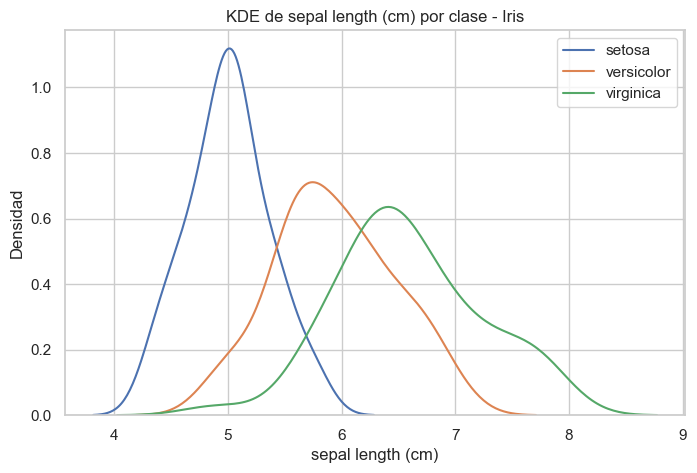

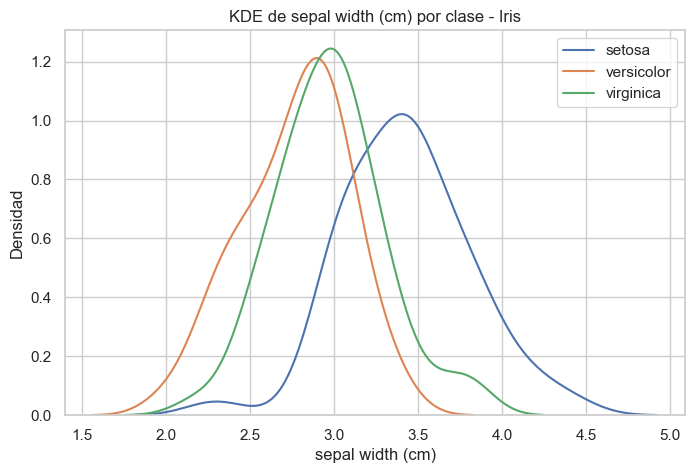

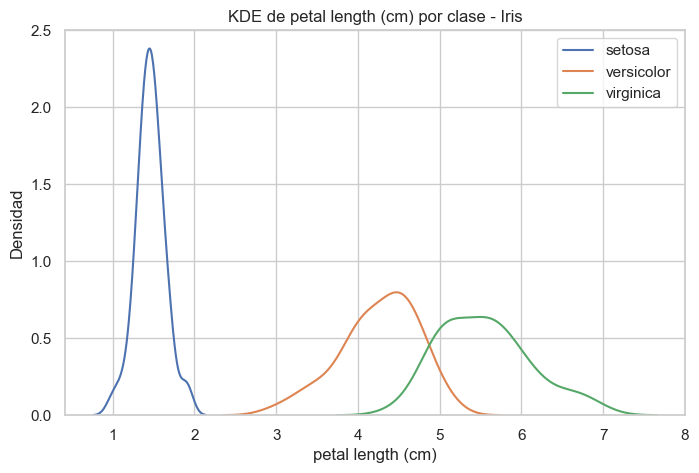

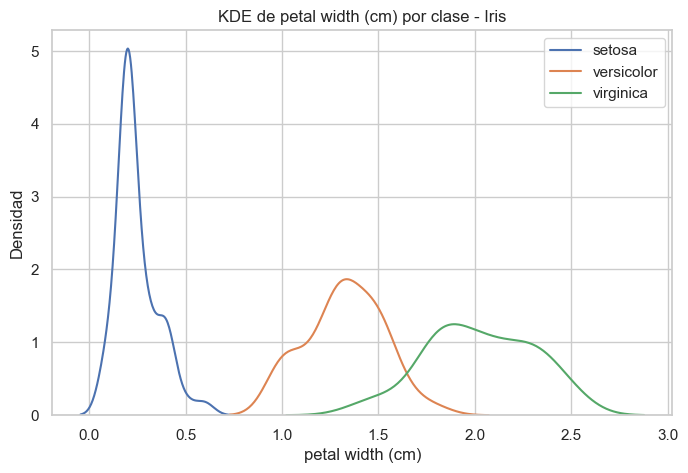


Matrices de correlación por clase:


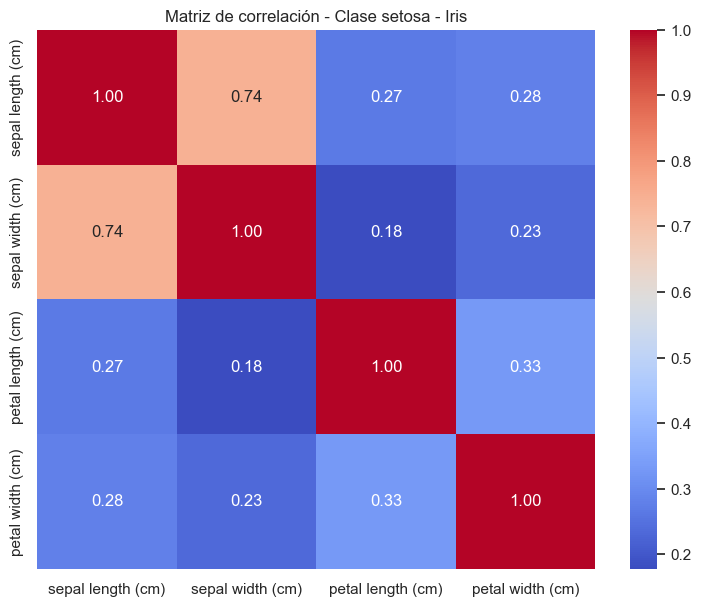

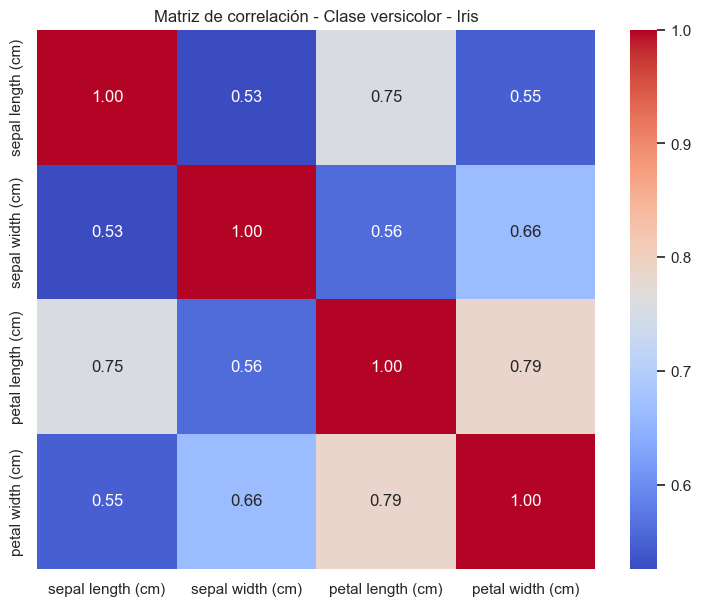

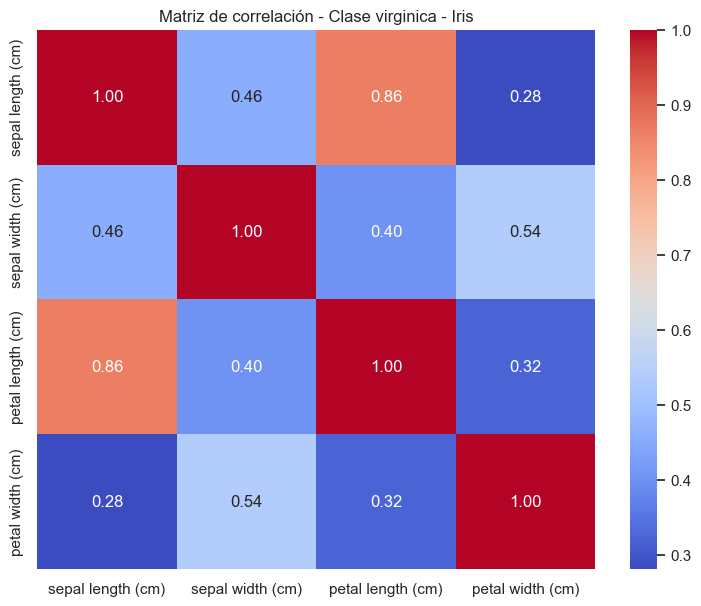


Hold-Out 80/20 - Naive Bayes Manual
Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Hold-Out 80/20 - GaussianNB Scikit-Learn
Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


10-Fold Cross-Validation - Manual
Accuracy promedio: 0.9600
Desviación estándar: 0.0533

10-Fold Cross-Validation - Scikit-L

In [27]:
iris = load_iris()
resumen_iris = analizar_dataset("Iris", iris)


## Interpretación del análisis de Iris

En Iris, las probabilidades a priori quedaron exactamente balanceadas: cada clase tiene una probabilidad de **0.3333**. Esto coincide con que el dataset tiene **50 muestras de Setosa, 50 de Versicolor y 50 de Virginica**, así que el modelo no empieza favoreciendo a una clase por aparecer más veces.

En Hold-Out 80/20, tanto la implementación manual como `GaussianNB` obtuvieron un **accuracy de 0.9667**. En la matriz de confusión se observa que sólo hubo **1 error de 30 muestras de prueba**: una flor Versicolor fue clasificada como Virginica. Setosa quedó perfecta en esta prueba, con **precision = 1.00, recall = 1.00 y f1-score = 1.00**.

También se nota que las variables del pétalo aportan bastante para separar las clases. Por ejemplo, en Versicolor la correlación entre `petal length (cm)` y `petal width (cm)` fue de **0.79**, mientras que en Virginica la relación más alta fue entre `sepal length (cm)` y `petal length (cm)`, con **0.86**. Esto explica por qué el modelo funciona bien, pero también muestra que la independencia entre características no se cumple por completo.

En 10-Fold Cross Validation, el modelo manual y Scikit-Learn dieron el mismo promedio: **0.9600**, con desviación estándar de **0.0533**. En Leave-One-Out ambos quedaron en **0.9533**. O sea, el desempeño fue alto, aunque no perfecto, y eso hace más creíble el resultado que simplemente decir que “clasifica bien”.


# 8. Análisis del dataset Wine

Wine fue más complicado de leer que Iris porque tiene trece características. Aquí ya no basta con ver dos o tres gráficas, porque hay más variables químicas y algunas se relacionan entre sí.

Aun así, fue útil usar el mismo procedimiento para comparar los resultados. En este dataset se puede ver mejor cómo Naive Bayes sigue funcionando aunque el supuesto de independencia no sea tan limpio.



DATASET: Wine

Número de muestras: 178
Número de características: 13
Clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Probabilidades a priori por clase:


,Probabilidad a priori
class_name,
class_1,0.398876
class_0,0.331461
class_2,0.269663



Media y desviación estándar por característica y clase:

Clase: class_0


,mean,std
alcohol,13.744746,0.462125
malic_acid,2.010678,0.688549
ash,2.455593,0.227166
alcalinity_of_ash,17.037288,2.546322
magnesium,106.338983,10.498949
total_phenols,2.840169,0.338961
flavanoids,2.982373,0.397494
nonflavanoid_phenols,0.290000,0.070049
proanthocyanins,1.899322,0.412109
color_intensity,5.528305,1.238573



Clase: class_1


,mean,std
alcohol,12.278732,0.537964
malic_acid,1.932676,1.015569
ash,2.244789,0.315467
alcalinity_of_ash,20.238028,3.349770
magnesium,94.549296,16.753497
total_phenols,2.258873,0.545361
flavanoids,2.080845,0.705701
nonflavanoid_phenols,0.363662,0.123961
proanthocyanins,1.630282,0.602068
color_intensity,3.086620,0.924929



Clase: class_2


,mean,std
alcohol,13.153750,0.530241
malic_acid,3.333750,1.087906
ash,2.437083,0.184690
alcalinity_of_ash,21.416667,2.258161
magnesium,99.312500,10.890473
total_phenols,1.678750,0.356971
flavanoids,0.781458,0.293504
nonflavanoid_phenols,0.447500,0.124140
proanthocyanins,1.153542,0.408836
color_intensity,7.396250,2.310942



Gráficas KDE por característica:


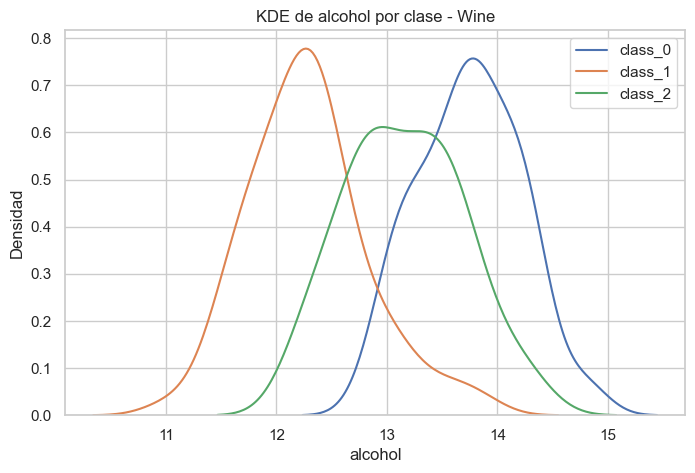

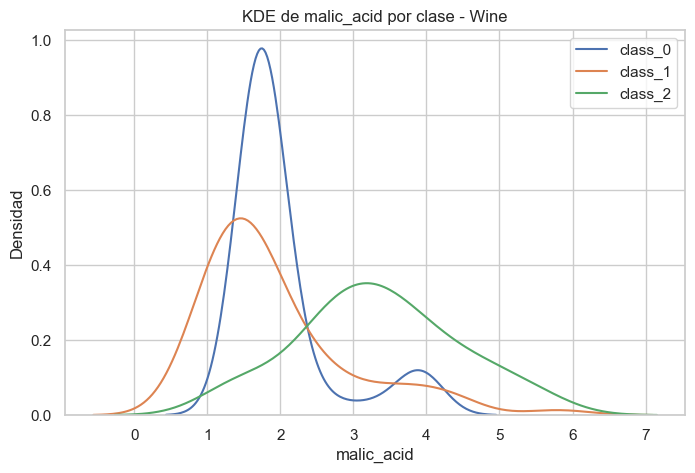

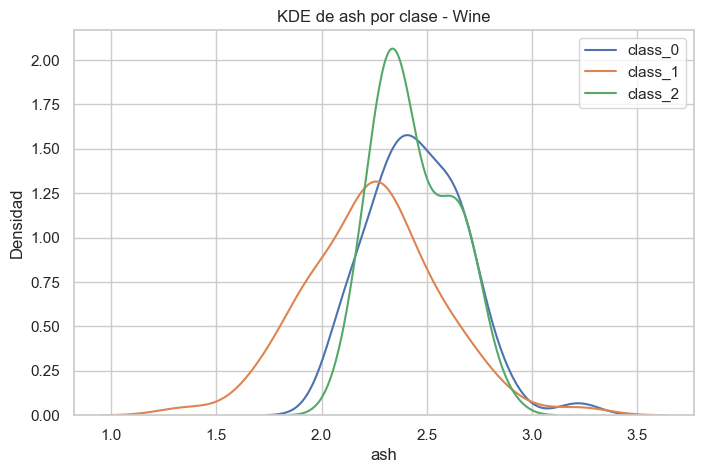

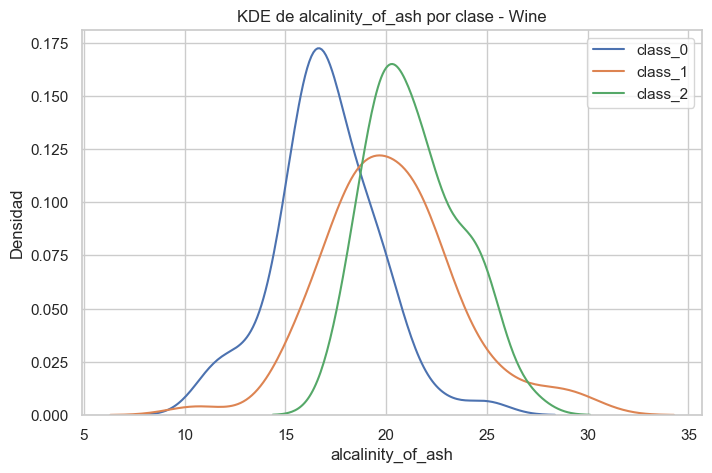

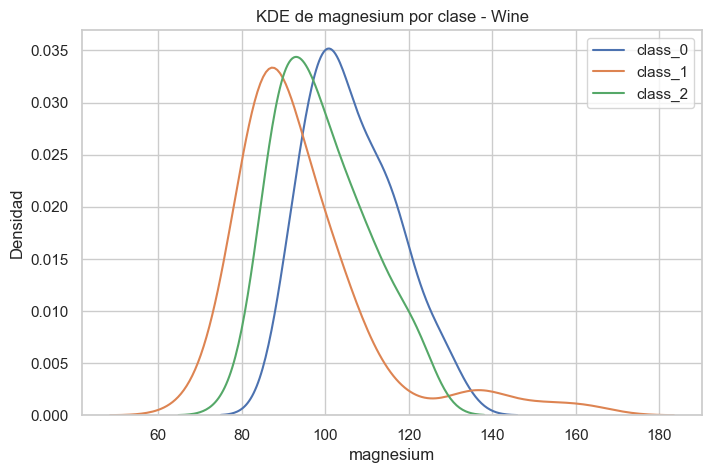

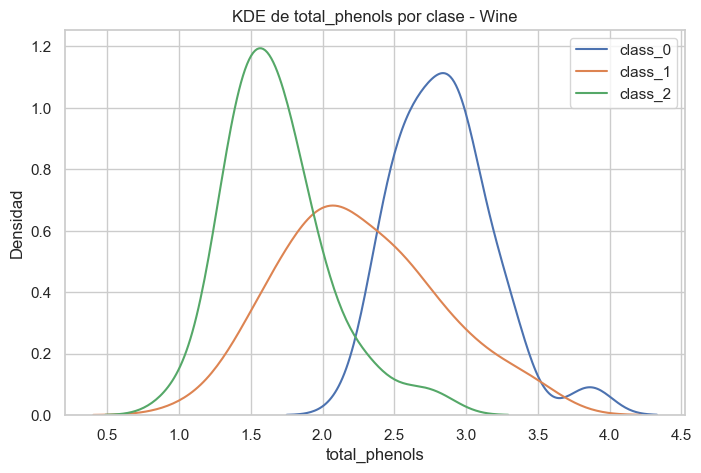

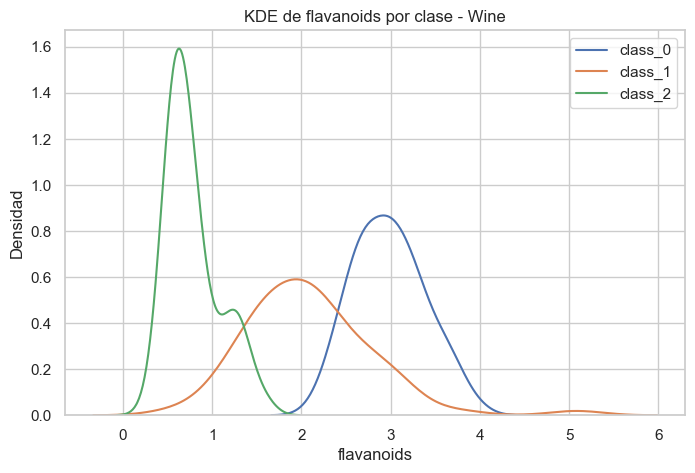

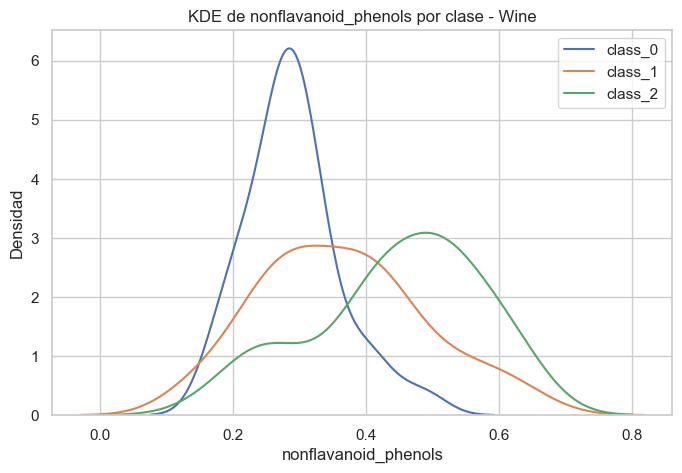

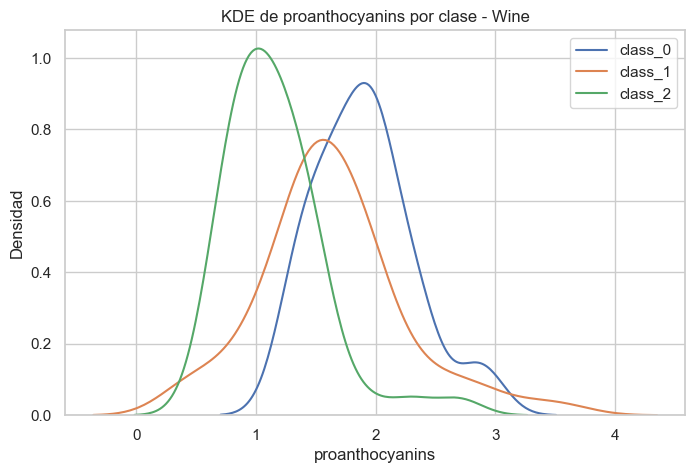

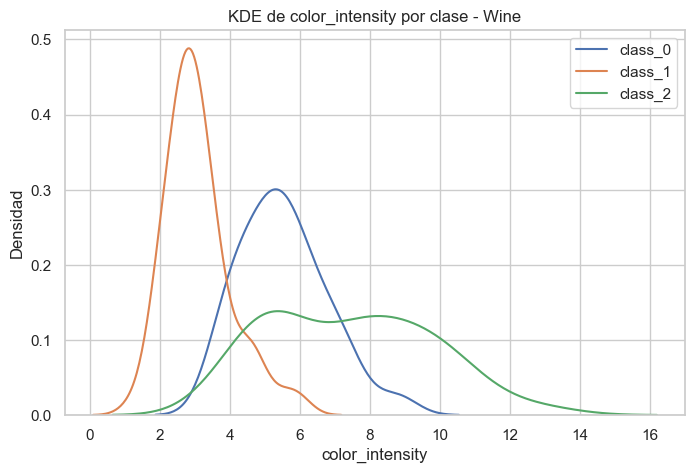

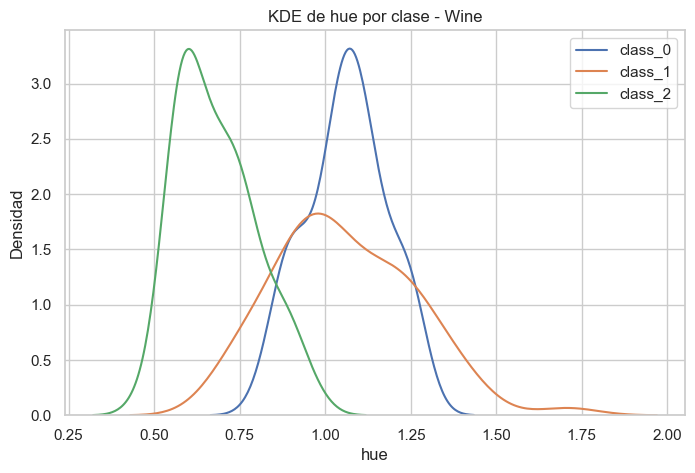

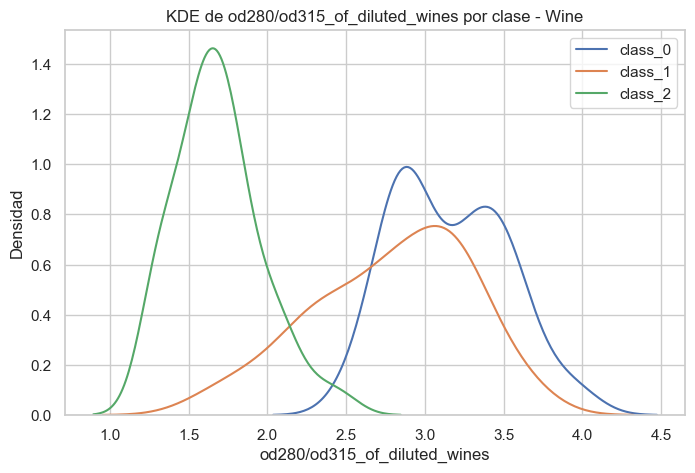

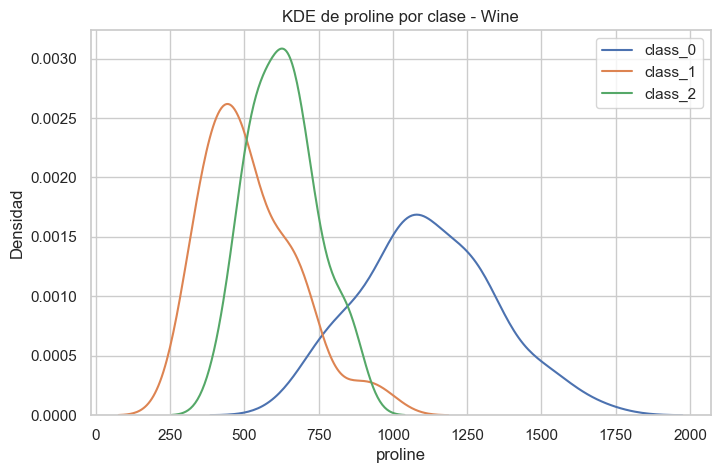


Matrices de correlación por clase:


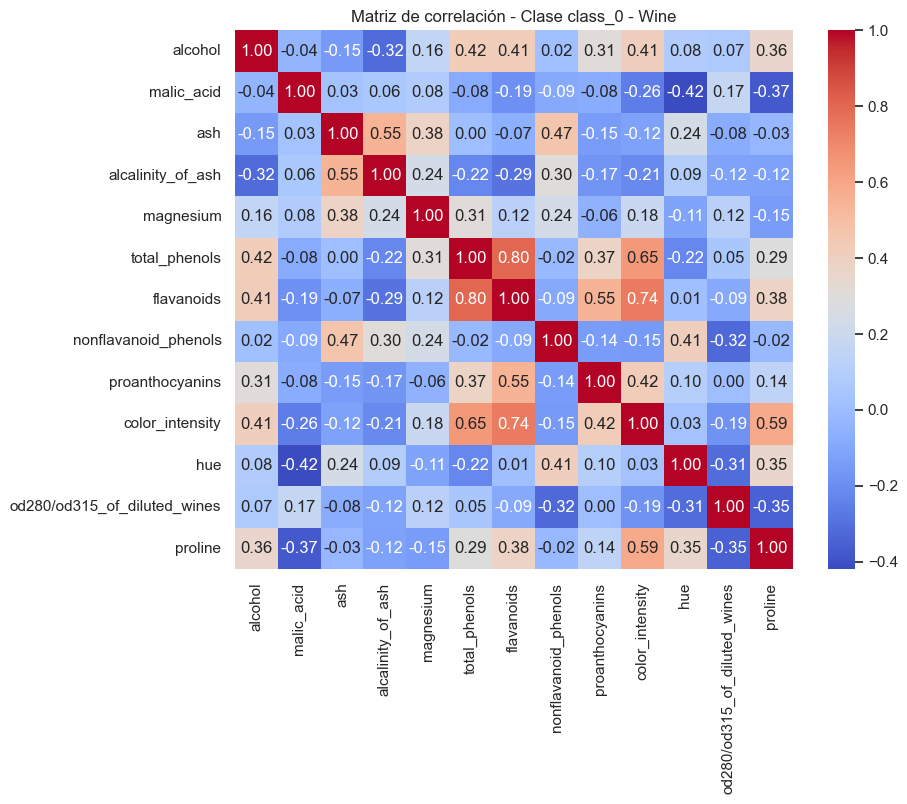

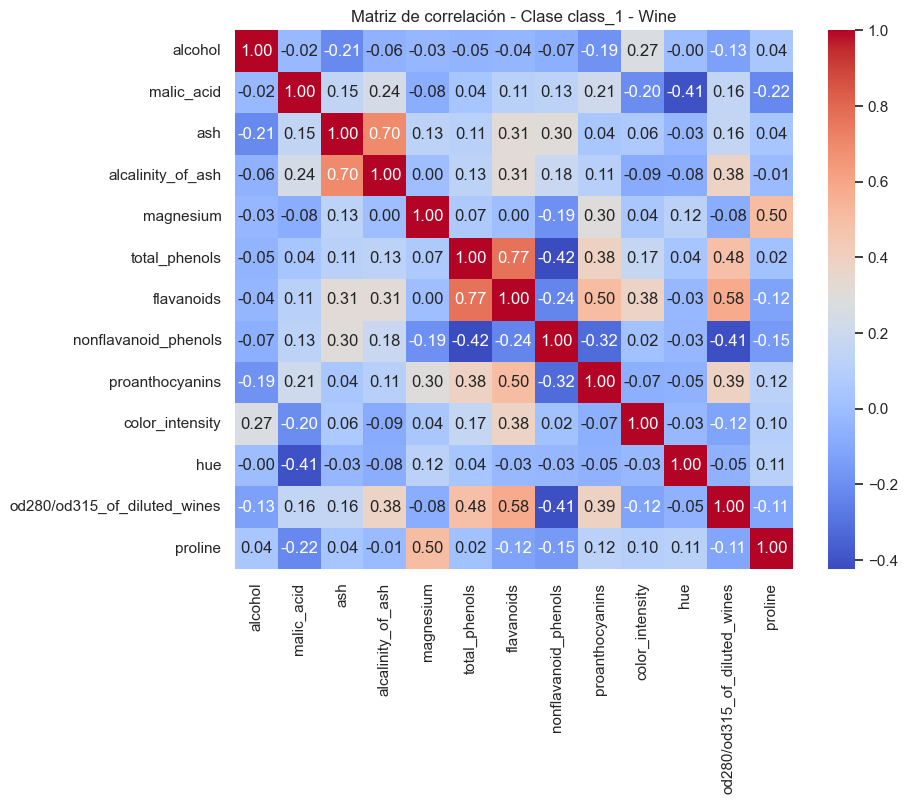

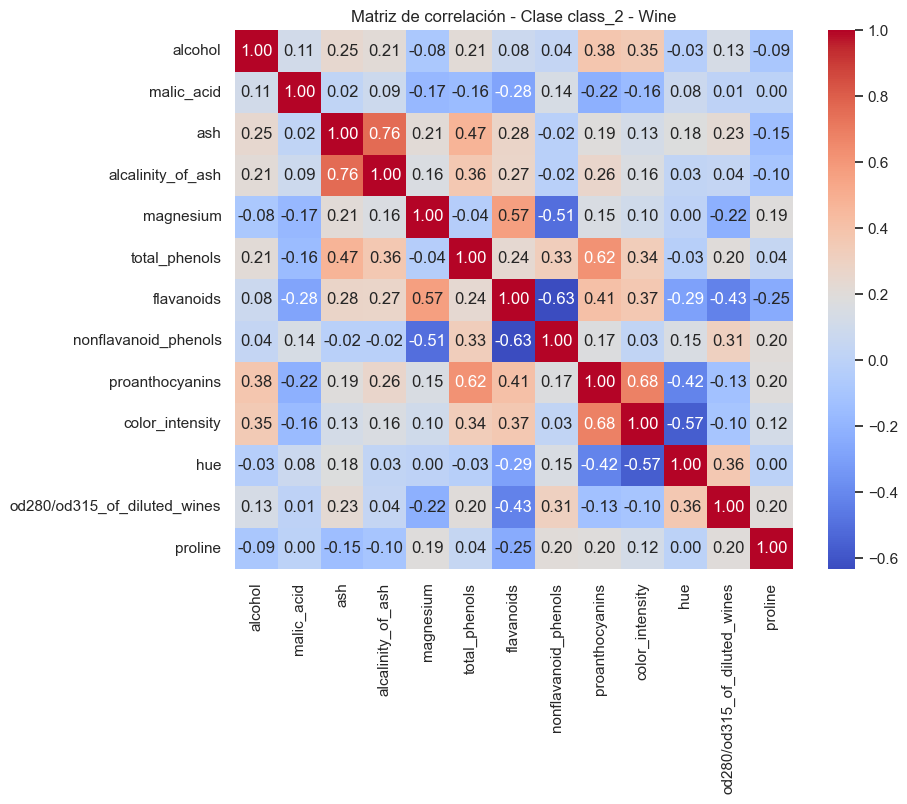


Hold-Out 80/20 - Naive Bayes Manual
Accuracy: 0.9722
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36


Hold-Out 80/20 - GaussianNB Scikit-Learn
Accuracy: 0.9722
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36


10-Fold Cross-Validation - Manual
Accuracy promedio: 0.9778
Desviación estándar: 0.0369

10-Fold Cross-Validation - Scikit-L

In [28]:
wine = load_wine()
resumen_wine = analizar_dataset("Wine", wine)


## Interpretación del análisis de Wine

En Wine, las probabilidades a priori ya no quedaron balanceadas. La clase con más muestras fue **class_1**, con probabilidad **0.3989**; después quedó **class_0** con **0.3315** y finalmente **class_2** con **0.2697**. Esto sí cambia un poco el punto de partida del modelo, porque no todas las clases aparecen con la misma frecuencia.

En Hold-Out 80/20, la implementación manual y Scikit-Learn obtuvieron el mismo **accuracy de 0.9722**. La matriz de confusión muestra **1 error de 36 muestras de prueba**: una muestra de `class_1` fue clasificada como `class_0`. La clase que mejor salió fue `class_2`, con **precision = 1.00, recall = 1.00 y f1-score = 1.00**. En cambio, `class_1` tuvo **recall = 0.9286**, justo por ese error.

Las correlaciones también muestran que el supuesto de independencia no se cumple de forma estricta. Por ejemplo, en `class_0`, `total_phenols` y `flavanoids` tuvieron correlación de **0.80**; en `class_1` esas mismas variables tuvieron **0.77**. En `class_2`, `ash` y `alcalinity_of_ash` llegaron a **0.76**, y `flavanoids` con `nonflavanoid_phenols` tuvo una correlación negativa de **-0.63**. Estos valores son bastante altos, así que no sería correcto decir que las variables son independientes.

A pesar de esas correlaciones, los resultados fueron muy buenos: en 10-Fold Cross Validation se obtuvo **0.9778** de accuracy promedio, con desviación estándar de **0.0369**, y en Leave-One-Out el accuracy fue **0.9775**. Me llamó la atención que Wine, aunque tiene más variables y parece más difícil, terminó dando un rendimiento ligeramente mayor que Iris en validaciones más completas.


# 9. Comparación general de resultados

Después de analizar ambos datasets, se reúnen los resultados principales en una sola tabla. Esto facilita comparar el comportamiento del modelo manual contra Scikit-Learn.


In [29]:
resultados = pd.DataFrame([resumen_iris, resumen_wine])
resultados


,Dataset,Hold-Out Manual,Hold-Out Scikit-Learn,10-Fold Manual,10-Fold Scikit-Learn,LOO Manual,LOO Scikit-Learn
0,Iris,0.966667,0.966667,0.960000,0.960000,0.953333,0.953333
1,Wine,0.972222,0.972222,0.977778,0.977778,0.977528,0.977528


La comparación con Scikit-Learn sirvió como una especie de revisión de seguridad. Si la implementación manual obtiene resultados iguales o muy cercanos, entonces es más probable que los cálculos de medias, desviaciones estándar, probabilidades a priori y verosimilitudes estén bien planteados.

También se ve que Hold-Out es rápido, pero depende mucho de la partición. En este notebook no salió mal, pero por eso se agregaron 10-Fold y Leave-One-Out: dan una visión menos dependiente de una sola división del dataset.


# 10. Discusión

Lo que más se notó en la práctica es que Naive Bayes no debe evaluarse sólo con el accuracy. En Iris y Wine los resultados fueron altos, pero al revisar las matrices de correlación se ve que varias características sí están relacionadas. Entonces, aunque el modelo funciona, su supuesto principal no se cumple de manera perfecta.

En Iris esto se entiende rápido porque las medidas de una flor naturalmente pueden crecer juntas. Por ejemplo, en Versicolor la correlación entre longitud y ancho del pétalo fue de **0.79**. En Wine pasa algo parecido con las variables químicas: `total_phenols` y `flavanoids` llegaron a **0.80** en `class_0`. O sea, el modelo está trabajando bien, pero no porque los datos sean ideales.

Una parte que sí me costó más fue interpretar Wine. Con trece características, las gráficas KDE ayudan, pero también se vuelve fácil perderse entre tantas variables. En ese caso, la tabla de resultados y las correlaciones fueron más útiles que intentar explicar cada gráfica una por una.

También fue interesante que la implementación manual y Scikit-Learn dieran los mismos accuracies principales: **0.9667** en Hold-Out para Iris y **0.9722** para Wine. Eso no significa que el código manual sea tan robusto como una biblioteca profesional, pero sí indica que la lógica básica quedó bien implementada.

En resumen, la práctica muestra que Gaussian Naive Bayes puede ser bastante competitivo en datasets pequeños y medianos, incluso cuando las variables no son totalmente independientes. Eso sí, revisar únicamente el resultado final sería quedarse con una parte muy superficial del análisis.


# 11. Conclusiones

1. Se implementó manualmente un clasificador Naive Bayes Gaussiano usando probabilidades a priori, medias y desviaciones estándar por clase.

2. La comparación con Scikit-Learn fue útil porque los resultados coincidieron en las pruebas principales. Por ejemplo, en Hold-Out se obtuvo **0.9667** para Iris y **0.9722** para Wine con ambas implementaciones.

3. Iris fue el dataset más sencillo de interpretar. Setosa quedó clasificada sin errores en la prueba Hold-Out, pero Versicolor sí tuvo un caso confundido con Virginica.

4. Wine no salió tan fácil de explicar como esperábamos. Aunque tuvo buen accuracy, sus trece características hacen que las correlaciones y las gráficas sean más difíciles de resumir sin perder detalle.

5. Las matrices de correlación mostraron que la independencia entre variables no se cumple completamente. Aun así, el modelo siguió dando buenos resultados, lo cual confirma que Naive Bayes puede ser práctico aunque su supuesto no sea perfecto.

6. 10-Fold Cross Validation y Leave-One-Out dieron una evaluación más completa que Hold-Out, porque no dependen de una sola partición de entrenamiento y prueba.

7. La parte manual del algoritmo ayudó a entender mejor qué hace `GaussianNB` por dentro. Usar la biblioteca es más rápido, pero programarlo paso a paso deja más claro de dónde salen las probabilidades.


# 12. Referencias

- Scikit-learn developers. (2026). *sklearn.naive_bayes.GaussianNB*. En *Scikit-learn 1.8.0 documentation*. Recuperado el 2 de junio de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

- Scikit-learn developers. (2026). *sklearn.datasets.load_iris*. En *Scikit-learn 1.8.0 documentation*. Recuperado el 2 de junio de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html

- Scikit-learn developers. (2026). *sklearn.datasets.load_wine*. En *Scikit-learn 1.8.0 documentation*. Recuperado el 2 de junio de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html

- Scikit-learn developers. (2026). *sklearn.model_selection.train_test_split*. En *Scikit-learn 1.8.0 documentation*. Recuperado el 2 de junio de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.

- Russell, S., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
